# Evaluating Re-identification Risk in De-identified Health datasets
__Author__: Bryant Cornwell | __Date__: February 2026

## Project Overivew
In the healthcare ecosystem, the ability to share data for research is often difficult due to the highly sensitive nature and HIPAA law to protect patient privacy. By simulating a Real-World Data (RWD) scenario, I evaluate how de-identification via multiplicative noise affects the validity of clinical interaction effects while measuring the mitigation of linkage attack risks.

## Tech Stack
- __Language:__ Python (Pandas,  Numpy, Scipy, Statsmodels)
- __Documentation__: Markdown (.ipynb). Future plans to document in LaTeX (.tex to .pdf)

In [1]:
import sys

# Shell command to upgrade pip
!{sys.executable} -m pip install --upgrade pip

In [2]:
# IPython magic command to install requirements
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import statsmodels.formula.api as smf

from scipy import stats

## Methodology

- Generate Data
- Apply Perturbation to the Existing Data
- Hypothesis Testing: Original VS. Noisy
- Results and Validation

Simple A/B Test:
- Group A stays 5 days on average.
- Group B stays 7 days on average.

### Simulating real-world patient data

Health data was chosen for its highly sensitive nature. Reflecting on my previous experience researching scalability and efficiency of different database models for big health data, one future consideration was to incorporate robust security layers to ensure HIPAA compliance and data privacy for cloud-based database models.

It is important to note that both age and hospital stay duration data naturally have non-negative values, but follow different distributions.

Age follows a normal distribution, but used truncated normal distribution to ensure ages were generate between 0 and 100. Hospital stay duration (in days) is naturally right-skewed and follows a count model. The Poisson distribution was chosen to model the hospital length of stay (LOS).

Basic assumption: modeling data on distributions will provide small error compared to real data.

In [4]:
def truncate_norm_age(mean, sd, lower, upper, size):
    a = (lower - mean) / sd
    b = (upper - mean) / sd
    return stats.truncnorm.rvs(a=a, b=b, loc=mean, scale=sd, size=size)

In [5]:
mean_age = 50
std_dev = 15
n_patients = 1000
true_lam = 5.0  # Average stay duration is 5 days

In [6]:
# Generate data
# Group B stays 2 days longer on average
np.random.seed(42)

# 50/50 split population split
group_size = n_patients//2
group_a_stays = np.random.poisson(lam=true_lam, size=group_size)
group_b_stays = np.random.poisson(lam=true_lam+2, size=group_size)

df = pd.DataFrame({
    'age': truncate_norm_age(mean=mean_age, sd=std_dev, lower=0, upper=100, size=n_patients).astype(int),
    'treatment': ['A'] * group_size + ['B'] * group_size,
    'stay_duration': np.concatenate([group_a_stays, group_b_stays])
})

### Applying Privacy Noise to Patient Data

#### Handling Negative Duration

Although additive noise differential privacy mechanisms such as adding Laplace noise is a common and fundamental technique, it can produce negative values that are semantically not possible for non-negative quantities like duration. This can be handled a couple different ways.

1. Truncating or clipping the negative Laplace noise that to zero (same day release from hospital). However, this introduces bias towards zero.
2. Use multiplicative noise mechanism (log-normal or exponential). Avoiding the bias altogether.



Source: [[1]](#references), [[2]](#references), [[3]](#references)

To apply privacy noise to the existing data, I chose Log-Normal (multiplicative) noise since the distribution bounds are (0, ∞) which will guarantee non-negative values. This process of taking existing data and masking it is called data perturbation.

In [7]:
# Apply Perturbation to the existing data
# 'sigma' controls the privacy level (higher sigma = more privacy)
sigma_low = 0.2
sigma_high = 1.5
noise_low = np.random.lognormal(mean=0, sigma=sigma_low, size=n_patients)
noise_high = np.random.lognormal(mean=0, sigma=sigma_high, size=n_patients)

df['age_noisy'] = round(df['age'] * np.random.lognormal(0, 0.05, n_patients)).astype(int)

# Apply multiplicative noise to the actual records. Round and convert to match the original data type.
df['stay_duration_noisy_low'] = round(df['stay_duration'] * noise_low).astype(int)
df['stay_duration_noisy_high'] = round(df['stay_duration'] * noise_high).astype(int)


### Hypothesis Testing (t-test): Original VS. Noisy

In [8]:
# Hypothesis testing: original VS. noisy
t_orig, p_orig = stats.ttest_ind(df[df['treatment']=='A']['stay_duration'],
                                 df[df['treatment']=='B']['stay_duration'])

t_noisy_low, p_noisy_low = stats.ttest_ind(df[df['treatment']=='A']['stay_duration_noisy_low'],
                                   df[df['treatment']=='B']['stay_duration_noisy_low'])
t_noisy_high, p_noisy_high = stats.ttest_ind(df[df['treatment']=='A']['stay_duration_noisy_high'],
                                   df[df['treatment']=='B']['stay_duration_noisy_high'])

## Results and Validation

### Sampling and Bias Evaluation
Since the LOS data was modeled using a distribution, the privacy level can be significantly higher while maintaining statistical significance. High privacy level was used to demonstrate a difference in p-value.


In [9]:
bootstrap_means = [df['age'].sample(frac=1,replace=True).mean() for i in range(n_patients)]
conf_int = np.percentile(bootstrap_means, [2.5, 97.5])

In [10]:
# Validation
print("-"*5, "A/B Test Results", "-"*5)
print(f"Original P-Value: {p_orig:.4f} (Statistically Significant)")
print(f"Low Noise P-Value:    {p_noisy_low:.4f} (Was the signal preserved?)")
print(f"High Noise P-Value:    {p_noisy_high:.4f} (Was the signal preserved?)")
print(f"95% CI for Mean Age (Bootstrap): {conf_int}")

for key, val in {"Low":p_noisy_low, "High":p_noisy_high}.items():
    print(f"\n{key} Noisy P-Value: ")
    if p_orig > 0.05:
        print("WARNING: Original test p-value exceeded significance threshold (0.05).")
    elif p_orig < 0.05 < val:
        print("WARNING: Type II Error introduced. Privacy noise destroyed statistical significance.")
    else:
        print("SUCCESS: Statistical utility preserved despite privacy measures.")

# Check for Negative Values
neg_count = (df['stay_duration_noisy_low'] < 0).sum()
print(f"\nTotal Negative Values: {neg_count}")

----- A/B Test Results -----
Original P-Value: 0.0000 (Statistically Significant)
Low Noise P-Value:    0.0000 (Was the signal preserved?)
High Noise P-Value:    0.0141 (Was the signal preserved?)
95% CI for Mean Age (Bootstrap): [47.648925 49.489225]

Low Noisy P-Value: 
SUCCESS: Statistical utility preserved despite privacy measures.

High Noisy P-Value: 
SUCCESS: Statistical utility preserved despite privacy measures.

Total Negative Values: 0


In [11]:
df.describe()

,age,stay_duration,age_noisy,stay_duration_noisy_low,stay_duration_noisy_high
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000
mean,48.585000,5.975000,48.6740,6.100000,19.461000
std,14.740015,2.595209,14.9316,3.004168,64.473695
min,1.000000,0.000000,1.0000,0.000000,0.000000
25%,39.000000,4.000000,39.0000,4.000000,2.000000
50%,49.000000,6.000000,48.5000,6.000000,5.000000
75%,58.000000,8.000000,58.0000,8.000000,15.000000
max,94.000000,14.000000,96.0000,20.000000,1472.000000


Since a multiplicative noise mechanism was used, the noisy stay duration has a significantly higher max value as a result of a higher privacy level used.

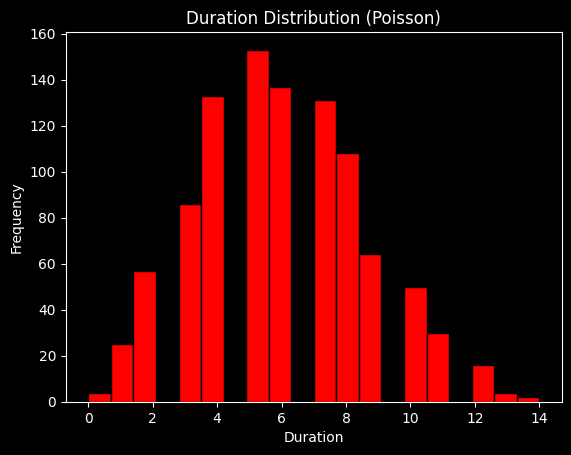

In [12]:
plt.hist(df.stay_duration, bins=20, color='red', edgecolor='black')
plt.title('Duration Distribution (Poisson)')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()

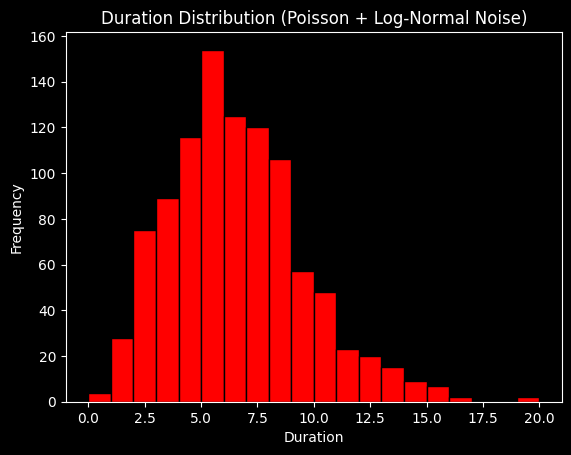

In [13]:
plt.hist(df.stay_duration_noisy_low, bins=20, color='red', edgecolor='black')
plt.title('Duration Distribution (Poisson + Log-Normal Noise)')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()

### Measure Re-identification Risk

Simulates a linkage attack by measuring 'uniqueness'. An attacker knows 'Age' and tries to link it to 'Stay Duration'.

In [14]:
df['age_match'] = df['age'].round(0)
df['age_noisy_match'] = df['age_noisy'].round(0)

counts_orig = df.groupby('age_match').size()
uniques_orig = counts_orig[counts_orig == 1].count()
print(uniques_orig)

16


In [15]:
counts_private = df.groupby('age_noisy_match').size()
uniques_private = counts_private[counts_private == 1].count()
print(uniques_private)

10


In [16]:
risk_raw = (uniques_orig / len(df)) * 100
risk_private = (uniques_private / len(df)) * 100

In [17]:
print("-"*5, "Re-identification Risk Audit", "-"*5)
print(f"Original Data Linkage Risk: {risk_raw:.2f}%")
print(f"Private Data Linkage Risk:  {risk_private:.2f}%")
print(f"Risk Reduction:             {risk_raw - risk_private:.2f}%")

----- Re-identification Risk Audit -----
Original Data Linkage Risk: 1.60%
Private Data Linkage Risk:  1.00%
Risk Reduction:             0.60%


## Observations and Reflection

For personal health data such as age and hospital length of stay, be cautious about using additive noise to mask the sensitive data as it can introduce impossible negative values. To maintain logical consistency without introducing bias caused by clipping, I implemented multiplicative Log-Normal perturbation which preserved the signal as evident in the p-values from the t-tests. Upon some further examination and research, the poisson distribution used for this experiment does not account of the amount of patients that are discharged same day. While the Poisson regression is a common way to model hospital length of stay data, health data exhibits more variance compared to this model's fixed variance (overdispersion). (Source: [[4]](#references))

Based on the count of unique ages and the size of the population, the risk of a linkage attack was already low. Applying a small amount of noise to the age reduced the risk to 1%. Other than adding noise, there are other ways to anonymize data such as suppression (redacting unique identifiers, such as Name, entirely) and generalization (replacing values with groups) (Source: [[5]](#references))

## Conclusion
The project goal to simulate a "Real-World Data" (RWD) scenario to assess whether a de-identified health dataset remains statistically representative of the population while measuring the risk of a "linkage attack" (re-identification) was achieved. Positivity of features/attributes were preserved and bias towards zero was minimized by utilizing multiplicative noise instead of clipping additive noise. The project can be improved by simulating hospital length of stay data using Negative Binomial regression, zero-inflated Poisson (ZIP) or zero-inflated generalized Poisson (ZIGP). (Source: [[4]](#references)) This project can be expanded by simulating more sensitive features and exploring more differential privacy techniques. In summary, the dataset remained valid for secondary analysis and resistant to re-identification.

## References <a id="references"></a>
[1] Differential privacy source (wiki): https://en.wikipedia.org/wiki/Differential_privacy

[2] Additive noise differential privacy mechanisms source (wiki): https://en.wikipedia.org/wiki/Additive_noise_differential_privacy_mechanisms

[3] Exponential mechanism source (wiki): https://en.wikipedia.org/wiki/Exponential_mechanism

[4] Assessment of length of stay in a general surgical unit using a zero-inflated generalized Poisson regression source: https://pmc.ncbi.nlm.nih.gov/articles/PMC6014792/

[5] K-anonymity source (wiki): https://en.wikipedia.org/wiki/K-anonymity
